Cell 1 - Import Libraries

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

Cell 2 - Load Cleaned Datasets

In [40]:
inventory = pd.read_csv("../data/cleaned/inventory.csv")
products = pd.read_csv("../data/cleaned/products.csv")
sales_header = pd.read_csv("../data/cleaned/sales_header.csv")
sales_lines = pd.read_csv("../data/cleaned/sales_lines.csv")

Cell 3 - Dataset Overview

In [41]:
datasets = {
    "Inventory": inventory,
    "Products": products,
    "Sales Header": sales_header,
    "Sales Lines": sales_lines
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Inventory,180,8
1,Products,30,25
2,Sales Header,20000,15
3,Sales Lines,130402,9


Cell 4 - Merge Inventory and Products

In [42]:
inventory_product = inventory.merge(
    products,
    on="product_id",
    how="left",
    suffixes=("_inventory", "_product")
)

inventory_product.head()

,product_id,branch_id,opening_stock,reorder_level_inventory,safety_stock_inventory,max_stock,current_stock,warehouse_bin,product_name,category,machine_type,brand,model_compatibility,unit_cost,unit_price,margin_percentage,gst_rate,weight_kg,dimensions_cm,material_type,warranty_months,reorder_level_product,safety_stock_product,max_stock_level,lead_time_days,criticality_level,usage_frequency,uom,last_purchase_price,last_purchase_date,last_purchase_date_year,last_purchase_date_month
0,P001,Del001,196,59,46,340,115928,C15,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3
1,P001,Pun001,198,70,43,349,109389,D16,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3
2,P001,Chn001,187,62,44,311,99373,A11,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3
3,P001,Hyd001,226,71,65,417,108772,A10,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3
4,P001,Kol001,263,94,58,475,103808,F03,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3


Cell 5 - Calculate Inventory Value

In [43]:
inventory_product["inventory_value"] = (
    inventory_product["current_stock"] *
    inventory_product["unit_cost"]
)

inventory_product[[
    "product_id",
    "product_name",
    "current_stock",
    "unit_cost",
    "inventory_value"
]].head()

,product_id,product_name,current_stock,unit_cost,inventory_value
0,P001,Hydraulic Pump Hp-300,115928,18950,2196835600
1,P001,Hydraulic Pump Hp-300,109389,18950,2072921550
2,P001,Hydraulic Pump Hp-300,99373,18950,1883118350
3,P001,Hydraulic Pump Hp-300,108772,18950,2061229400
4,P001,Hydraulic Pump Hp-300,103808,18950,1967161600


Cell 6 - Total Inventory Value

In [44]:
total_inventory_value = inventory_product["inventory_value"].sum()

print(f"Total Inventory Value : ₹{total_inventory_value:,.2f}")

Total Inventory Value : ₹281,292,677,410.00


Cell 7 - Merge Sales Data

In [45]:
sales = sales_lines.merge(
    sales_header,
    on="so_id",
    how="left"
)

sales.head()

,so_id,line_number,product_id,quantity,unit_price,gst_rate,line_total,gst_amount,line_grand_total,customer_id,branch_id,order_date,delivery_date,order_status,payment_terms,total_order_value,total_gst_amount,grand_total,sales_channel,order_date_year,order_date_month,delivery_date_year,delivery_date_month
0,So-990591,1,P018,19,11300,28,214700,60116.0,274816.0,C0070,Ahm001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,2022,5,2022,5
1,So-990591,2,P026,2,310,18,620,111.6,731.6,C0070,Ahm001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,2022,5,2022,5
2,So-990591,3,P026,3,310,18,930,167.4,1097.4,C0070,Ahm001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,2022,5,2022,5
3,So-990591,4,P013,9,1450,18,13050,2349.0,15399.0,C0070,Ahm001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,2022,5,2022,5
4,So-990591,5,P004,3,39800,28,119400,33432.0,152832.0,C0070,Ahm001,2022-05-24,2022-05-28,Delivered,Net 30,1345720,374439.6,1720159.6,Counter Sale,2022,5,2022,5


Cell 8 - Total Quantity Sold per Product

In [46]:
product_sales = sales.groupby(
    "product_id"
)["quantity"].sum().reset_index()

product_sales.rename(
    columns={"quantity":"quantity_sold"},
    inplace=True
)

product_sales.head()

,product_id,quantity_sold
0,P001,45389
1,P002,45342
2,P003,45684
3,P004,45575
4,P005,45026


Cell 9 - Inventory Turnover

In [47]:
turnover = inventory_product.merge(
    product_sales,
    on="product_id",
    how="left"
)

turnover["quantity_sold"] = turnover["quantity_sold"].fillna(0)

turnover["average_inventory"] = (
    turnover["opening_stock"] +
    turnover["current_stock"]
) / 2

turnover["inventory_turnover"] = (
    turnover["quantity_sold"] /
    turnover["average_inventory"]
)

turnover.head()

,product_id,branch_id,opening_stock,reorder_level_inventory,safety_stock_inventory,max_stock,current_stock,warehouse_bin,product_name,category,machine_type,brand,model_compatibility,unit_cost,unit_price,margin_percentage,gst_rate,weight_kg,dimensions_cm,material_type,warranty_months,reorder_level_product,safety_stock_product,max_stock_level,lead_time_days,criticality_level,usage_frequency,uom,last_purchase_price,last_purchase_date,last_purchase_date_year,last_purchase_date_month,inventory_value,quantity_sold,average_inventory,inventory_turnover
0,P001,Del001,196,59,46,340,115928,C15,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3,2196835600,45389,58062.0,0.781733
1,P001,Pun001,198,70,43,349,109389,D16,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3,2072921550,45389,54793.5,0.828365
2,P001,Chn001,187,62,44,311,99373,A11,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3,1883118350,45389,49780.0,0.911792
3,P001,Hyd001,226,71,65,417,108772,A10,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3,2061229400,45389,54499.0,0.832841
4,P001,Kol001,263,94,58,475,103808,F03,Hydraulic Pump Hp-300,Hydraulic,Excavator,Cat,Cat 320D,18950,24500,29.2,28,38.5,40X25X25,Steel,12,15,10,40,21,High,Medium,Piece,18500,2019-03-15,2019,3,1967161600,45389,52035.5,0.872270


Cell 10 - Top 10 Fast-Moving Products

In [48]:
fast_moving = turnover.sort_values(
    by="quantity_sold",
    ascending=False
)

fast_moving[[
    "product_name",
    "quantity_sold"
]].head(10)

,product_name,quantity_sold
169,Pressure Sensor Ps-90,47066
168,Pressure Sensor Ps-90,47066
171,Pressure Sensor Ps-90,47066
170,Pressure Sensor Ps-90,47066
173,Pressure Sensor Ps-90,47066
172,Pressure Sensor Ps-90,47066
54,Turbocharger Tb-900,46964
55,Turbocharger Tb-900,46964
56,Turbocharger Tb-900,46964
57,Turbocharger Tb-900,46964


Cell 11 - Top 10 Slow-Moving Products

In [49]:
slow_moving = turnover.sort_values(
    by="quantity_sold"
)

slow_moving[[
    "product_name",
    "quantity_sold"
]].head(10)

,product_name,quantity_sold
142,Track Roller Tr-60,44022
143,Track Roller Tr-60,44022
139,Track Roller Tr-60,44022
138,Track Roller Tr-60,44022
141,Track Roller Tr-60,44022
140,Track Roller Tr-60,44022
76,Seal Kit Sk-15,44081
77,Seal Kit Sk-15,44081
74,Seal Kit Sk-15,44081
75,Seal Kit Sk-15,44081


Cell 12 - Fast vs Slow Moving Chart

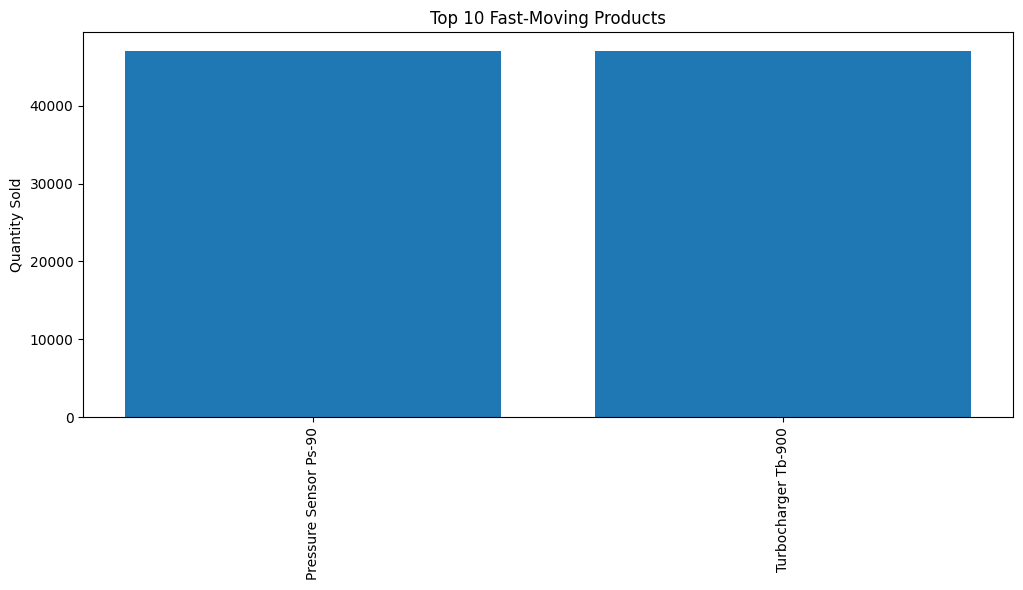

In [50]:
plt.figure(figsize=(12,5))

plt.bar(
    fast_moving.head(10)["product_name"],
    fast_moving.head(10)["quantity_sold"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Fast-Moving Products")

plt.ylabel("Quantity Sold")

plt.show()

Cell 13 - Bottom 10 Products Chart

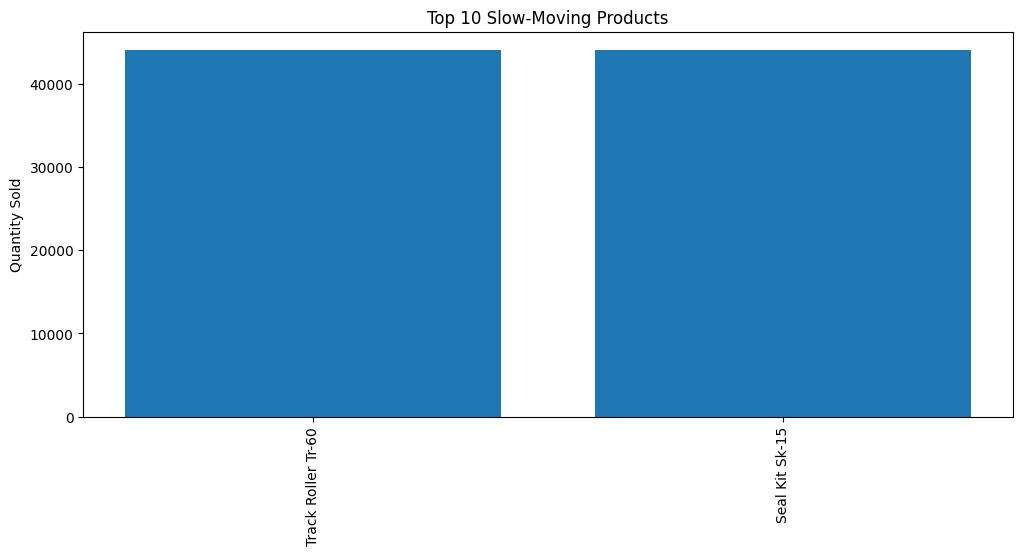

In [51]:
plt.figure(figsize=(12,5))

plt.bar(
    slow_moving.head(10)["product_name"],
    slow_moving.head(10)["quantity_sold"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Slow-Moving Products")

plt.ylabel("Quantity Sold")

plt.show()

Cell 14 - Dead Stock Analysis

In [52]:
dead_stock = turnover[
    (turnover["current_stock"] > 0) &
    (turnover["quantity_sold"] == 0)
]

print("Total Dead Stock Products:", len(dead_stock))

dead_stock[[
    "product_id",
    "product_name",
    "current_stock",
    "inventory_value"
]].head(20)

Total Dead Stock Products: 0


,product_id,product_name,current_stock,inventory_value


Cell 15 - Inventory Aging

In [53]:
inventory_product["last_purchase_date"] = pd.to_datetime(
    inventory_product["last_purchase_date"],
    errors="coerce"
)

today = pd.Timestamp.today()

inventory_product["inventory_age_days"] = (
    today - inventory_product["last_purchase_date"]
).dt.days

inventory_product[[
    "product_name",
    "inventory_age_days"
]].head()

,product_name,inventory_age_days
0,Hydraulic Pump Hp-300,2696
1,Hydraulic Pump Hp-300,2696
2,Hydraulic Pump Hp-300,2696
3,Hydraulic Pump Hp-300,2696
4,Hydraulic Pump Hp-300,2696


Cell 16 - Inventory Aging Categories

In [54]:
bins = [0, 30, 90, 180, np.inf]

labels = [
    "0-30 Days",
    "31-90 Days",
    "91-180 Days",
    "180+ Days"
]

inventory_product["aging_category"] = pd.cut(
    inventory_product["inventory_age_days"],
    bins=bins,
    labels=labels
)

inventory_product[
    "aging_category"
].value_counts()

aging_category
180+ Days      180
0-30 Days        0
31-90 Days       0
91-180 Days      0
Name: count, dtype: int64

Cell 17 - Inventory Aging Chart

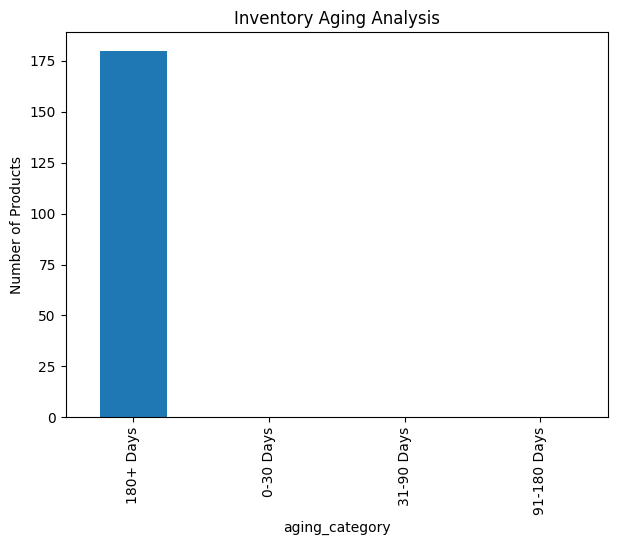

In [55]:
plt.figure(figsize=(7,5))

inventory_product["aging_category"].value_counts().plot(
    kind="bar"
)

plt.title("Inventory Aging Analysis")

plt.ylabel("Number of Products")

plt.show()

Cell 18 - ABC (Pareto) Classification

In [56]:
abc = inventory_product.sort_values(
    by="inventory_value",
    ascending=False
)

abc["cumulative_percentage"] = (
    abc["inventory_value"].cumsum()
    / abc["inventory_value"].sum()
) * 100

abc["ABC_Class"] = np.where(

    abc["cumulative_percentage"] <= 70,

    "A",

    np.where(

        abc["cumulative_percentage"] <= 90,

        "B",

        "C"
    )
)

abc.head()

,product_id,branch_id,opening_stock,reorder_level_inventory,safety_stock_inventory,max_stock,current_stock,warehouse_bin,product_name,category,machine_type,brand,model_compatibility,unit_cost,unit_price,margin_percentage,gst_rate,weight_kg,dimensions_cm,material_type,warranty_months,reorder_level_product,safety_stock_product,max_stock_level,lead_time_days,criticality_level,usage_frequency,uom,last_purchase_price,last_purchase_date,last_purchase_date_year,last_purchase_date_month,inventory_value,inventory_age_days,aging_category,cumulative_percentage,ABC_Class
86,P015,Chn001,239,91,57,370,113851,C20,Engine Block Eb-600,Engine,Excavator,Komatsu,Komatsu Pc300,95500,119000,24.6,28,320.0,160X70X65,Cast Iron,24,3,2,8,40,High,Low,Piece,94000,2023-06-17,2023,6,10872770500,1141,180+ Days,3.865287,A
87,P015,Hyd001,149,56,43,226,110035,A16,Engine Block Eb-600,Engine,Excavator,Komatsu,Komatsu Pc300,95500,119000,24.6,28,320.0,160X70X65,Cast Iron,24,3,2,8,40,High,Low,Piece,94000,2023-06-17,2023,6,10508342500,1141,180+ Days,7.601020,A
85,P015,Pun001,134,43,34,210,106048,A13,Engine Block Eb-600,Engine,Excavator,Komatsu,Komatsu Pc300,95500,119000,24.6,28,320.0,160X70X65,Cast Iron,24,3,2,8,40,High,Low,Piece,94000,2023-06-17,2023,6,10127584000,1141,180+ Days,11.201393,A
89,P015,Ahm001,85,28,24,131,105135,A13,Engine Block Eb-600,Engine,Excavator,Komatsu,Komatsu Pc300,95500,119000,24.6,28,320.0,160X70X65,Cast Iron,24,3,2,8,40,High,Low,Piece,94000,2023-06-17,2023,6,10040392500,1141,180+ Days,14.770768,A
84,P015,Del001,223,75,60,387,100967,E12,Engine Block Eb-600,Engine,Excavator,Komatsu,Komatsu Pc300,95500,119000,24.6,28,320.0,160X70X65,Cast Iron,24,3,2,8,40,High,Low,Piece,94000,2023-06-17,2023,6,9642348500,1141,180+ Days,18.198639,A


Cell 19 - ABC Summary

In [57]:
abc_summary = abc["ABC_Class"].value_counts()

abc_summary

ABC_Class
C    101
B     40
A     39
Name: count, dtype: int64

Cell 20 - ABC Classification Chart

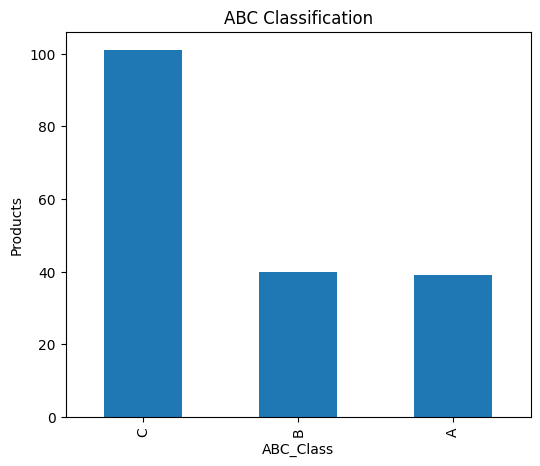

In [58]:
plt.figure(figsize=(6,5))

abc_summary.plot(kind="bar")

plt.title("ABC Classification")

plt.ylabel("Products")

plt.show()

Cell 21 - Products Below Reorder Level

In [59]:
below_reorder = inventory_product[
    inventory_product["current_stock"] <
    inventory_product["reorder_level_inventory"]
]

print("Products Below Reorder Level")

below_reorder.head(20)

Products Below Reorder Level


,product_id,branch_id,opening_stock,reorder_level_inventory,safety_stock_inventory,max_stock,current_stock,warehouse_bin,product_name,category,machine_type,brand,model_compatibility,unit_cost,unit_price,margin_percentage,gst_rate,weight_kg,dimensions_cm,material_type,warranty_months,reorder_level_product,safety_stock_product,max_stock_level,lead_time_days,criticality_level,usage_frequency,uom,last_purchase_price,last_purchase_date,last_purchase_date_year,last_purchase_date_month,inventory_value,inventory_age_days,aging_category


Cell 22 - Products Below Safety Stock

In [60]:
below_safety = inventory_product[
    inventory_product["current_stock"] <
    inventory_product["safety_stock_inventory"]
]

print("Products Below Safety Stock")

below_safety.head(20)

Products Below Safety Stock


,product_id,branch_id,opening_stock,reorder_level_inventory,safety_stock_inventory,max_stock,current_stock,warehouse_bin,product_name,category,machine_type,brand,model_compatibility,unit_cost,unit_price,margin_percentage,gst_rate,weight_kg,dimensions_cm,material_type,warranty_months,reorder_level_product,safety_stock_product,max_stock_level,lead_time_days,criticality_level,usage_frequency,uom,last_purchase_price,last_purchase_date,last_purchase_date_year,last_purchase_date_month,inventory_value,inventory_age_days,aging_category


Cell 23 - Inventory KPI Dashboard

In [61]:
kpis = pd.DataFrame({

    "Metric":[

        "Total Inventory Value",

        "Average Inventory",

        "Fast Moving Products",

        "Slow Moving Products",

        "Dead Stock Products",

        "ABC Category A",

        "ABC Category B",

        "ABC Category C"

    ],

    "Value":[

        round(
            inventory_product["inventory_value"].sum(),2
        ),

        round(
            inventory_product["current_stock"].mean(),2
        ),

        len(fast_moving.head(10)),

        len(slow_moving.head(10)),

        len(dead_stock),

        (abc["ABC_Class"]=="A").sum(),

        (abc["ABC_Class"]=="B").sum(),

        (abc["ABC_Class"]=="C").sum()

    ]

})

kpis

,Metric,Value
0,Total Inventory Value,2.812927e+11
1,Average Inventory,1.072404e+05
2,Fast Moving Products,1.000000e+01
3,Slow Moving Products,1.000000e+01
4,Dead Stock Products,0.000000e+00
5,ABC Category A,3.900000e+01
6,ABC Category B,4.000000e+01
7,ABC Category C,1.010000e+02


Cell 24 - Inventory Value by Category

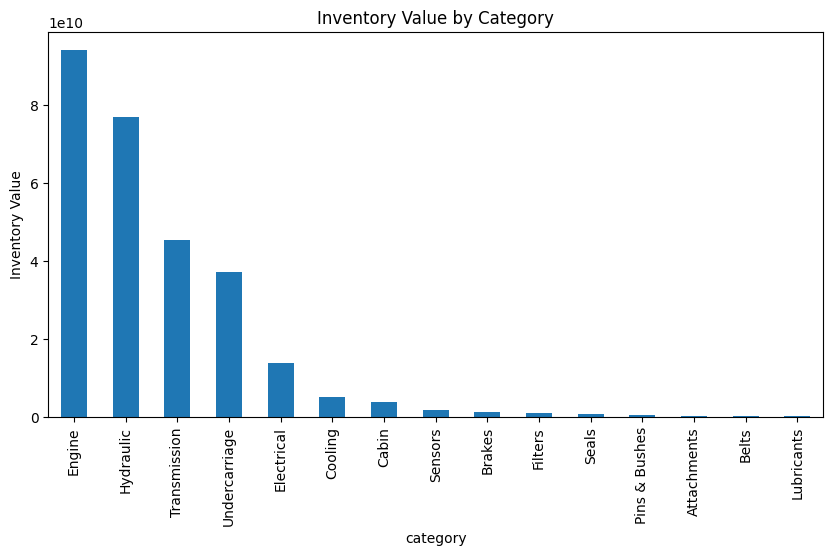

In [62]:
category_value = inventory_product.groupby(
    "category"
)["inventory_value"].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(10,5))

category_value.plot(kind="bar")

plt.title("Inventory Value by Category")

plt.ylabel("Inventory Value")

plt.show()

Cell 25 - Top 10 Inventory Value Products

In [63]:
top_inventory = inventory_product.sort_values(
    by="inventory_value",
    ascending=False
)

top_inventory[[
    "product_name",
    "current_stock",
    "inventory_value"
]].head(10)

,product_name,current_stock,inventory_value
86,Engine Block Eb-600,113851,10872770500
87,Engine Block Eb-600,110035,10508342500
85,Engine Block Eb-600,106048,10127584000
89,Engine Block Eb-600,105135,10040392500
84,Engine Block Eb-600,100967,9642348500
88,Engine Block Eb-600,96547,9220238500
80,Transmission Assembly Ta-800,114302,7829687000
79,Transmission Assembly Ta-800,113386,7766941000
78,Transmission Assembly Ta-800,111321,7625488500
81,Transmission Assembly Ta-800,111315,7625077500


Cell 26 - Top Inventory Value Chart

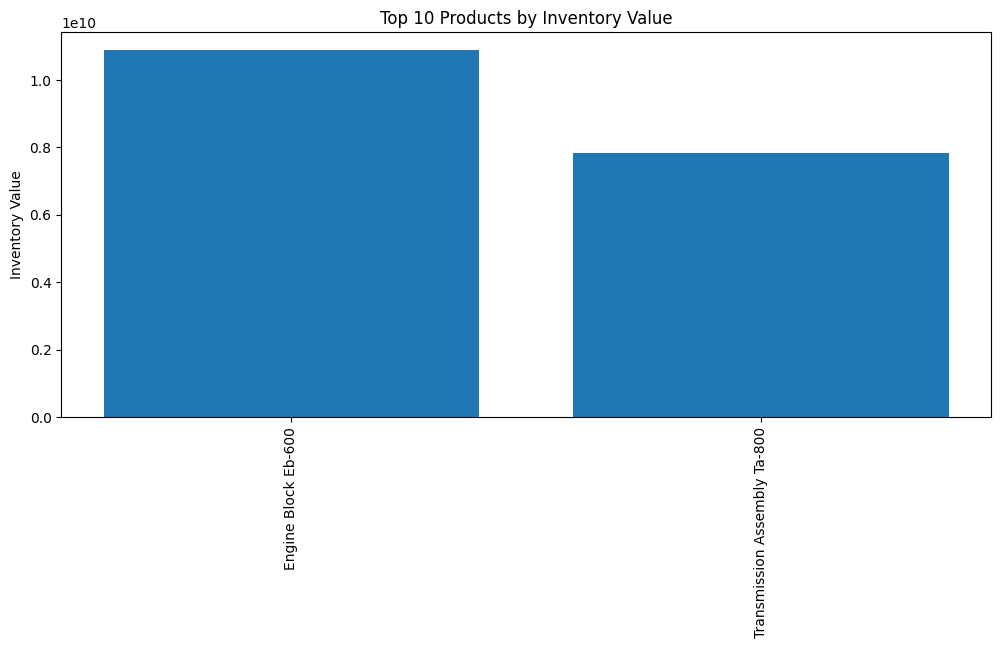

In [64]:
plt.figure(figsize=(12,5))

plt.bar(
    top_inventory.head(10)["product_name"],
    top_inventory.head(10)["inventory_value"]
)

plt.xticks(rotation=90)

plt.title("Top 10 Products by Inventory Value")

plt.ylabel("Inventory Value")

plt.show()

Cell 27 - Inventory Turnover Summary

In [65]:
turnover_summary = turnover[[
    "product_name",
    "quantity_sold",
    "average_inventory",
    "inventory_turnover"
]].sort_values(
    by="inventory_turnover",
    ascending=False
)

turnover_summary.head(10)

,product_name,quantity_sold,average_inventory,inventory_turnover
112,Swing Motor Swm-350,45971,44472.5,1.033695
173,Pressure Sensor Ps-90,47066,48873.0,0.963027
94,Radiator Rd-250,46306,48988.5,0.945242
30,Alternator Alt-500,46731,49744.5,0.939420
53,Starter Motor Sm-700,44946,47957.0,0.937215
88,Engine Block Eb-600,45222,48419.5,0.933963
149,Cabin Glass Cg-20,45598,48838.5,0.933649
40,Hydraulic Hose Hh-60,46468,49868.0,0.931820
158,O-Ring Set Or-50,45678,49028.5,0.931662
123,Boom Cylinder Bc-400,46364,49809.5,0.930826


Cell 28 - Business Insights

In [66]:
print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print(f"Total Inventory Value : ₹{inventory_product['inventory_value'].sum():,.2f}")

print(f"Average Inventory : {inventory_product['current_stock'].mean():.2f}")

print(f"Fast Moving Products : {len(fast_moving.head(10))}")

print(f"Slow Moving Products : {len(slow_moving.head(10))}")

print(f"Dead Stock Products : {len(dead_stock)}")

print(f"Products Below Reorder Level : {len(below_reorder)}")

print(f"Products Below Safety Stock : {len(below_safety)}")

BUSINESS INSIGHTS
Total Inventory Value : ₹281,292,677,410.00
Average Inventory : 107240.37
Fast Moving Products : 10
Slow Moving Products : 10
Dead Stock Products : 0
Products Below Reorder Level : 0
Products Below Safety Stock : 0


Cell 29 - Recommendations

In [67]:
recommendations = [

    "Prioritize replenishment of products below reorder level.",

    "Reduce excess inventory for slow-moving products.",

    "Review dead stock and consider liquidation or discounting.",

    "Focus inventory control on Class A products.",

    "Improve demand forecasting to optimize stock levels."

]

print("BUSINESS RECOMMENDATIONS")
print("-"*60)

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

BUSINESS RECOMMENDATIONS
------------------------------------------------------------
1. Prioritize replenishment of products below reorder level.
2. Reduce excess inventory for slow-moving products.
3. Review dead stock and consider liquidation or discounting.
4. Focus inventory control on Class A products.
5. Improve demand forecasting to optimize stock levels.


Cell 30 - Final KPI Summary

In [68]:
summary = pd.DataFrame({

    "Analysis":[

        "Inventory Value",

        "Inventory Turnover",

        "Fast Moving Products",

        "Slow Moving Products",

        "Dead Stock",

        "ABC Classification",

        "Inventory Aging"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed"

    ]

})

summary

,Analysis,Status
0,Inventory Value,Completed
1,Inventory Turnover,Completed
2,Fast Moving Products,Completed
3,Slow Moving Products,Completed
4,Dead Stock,Completed
5,ABC Classification,Completed
6,Inventory Aging,Completed
